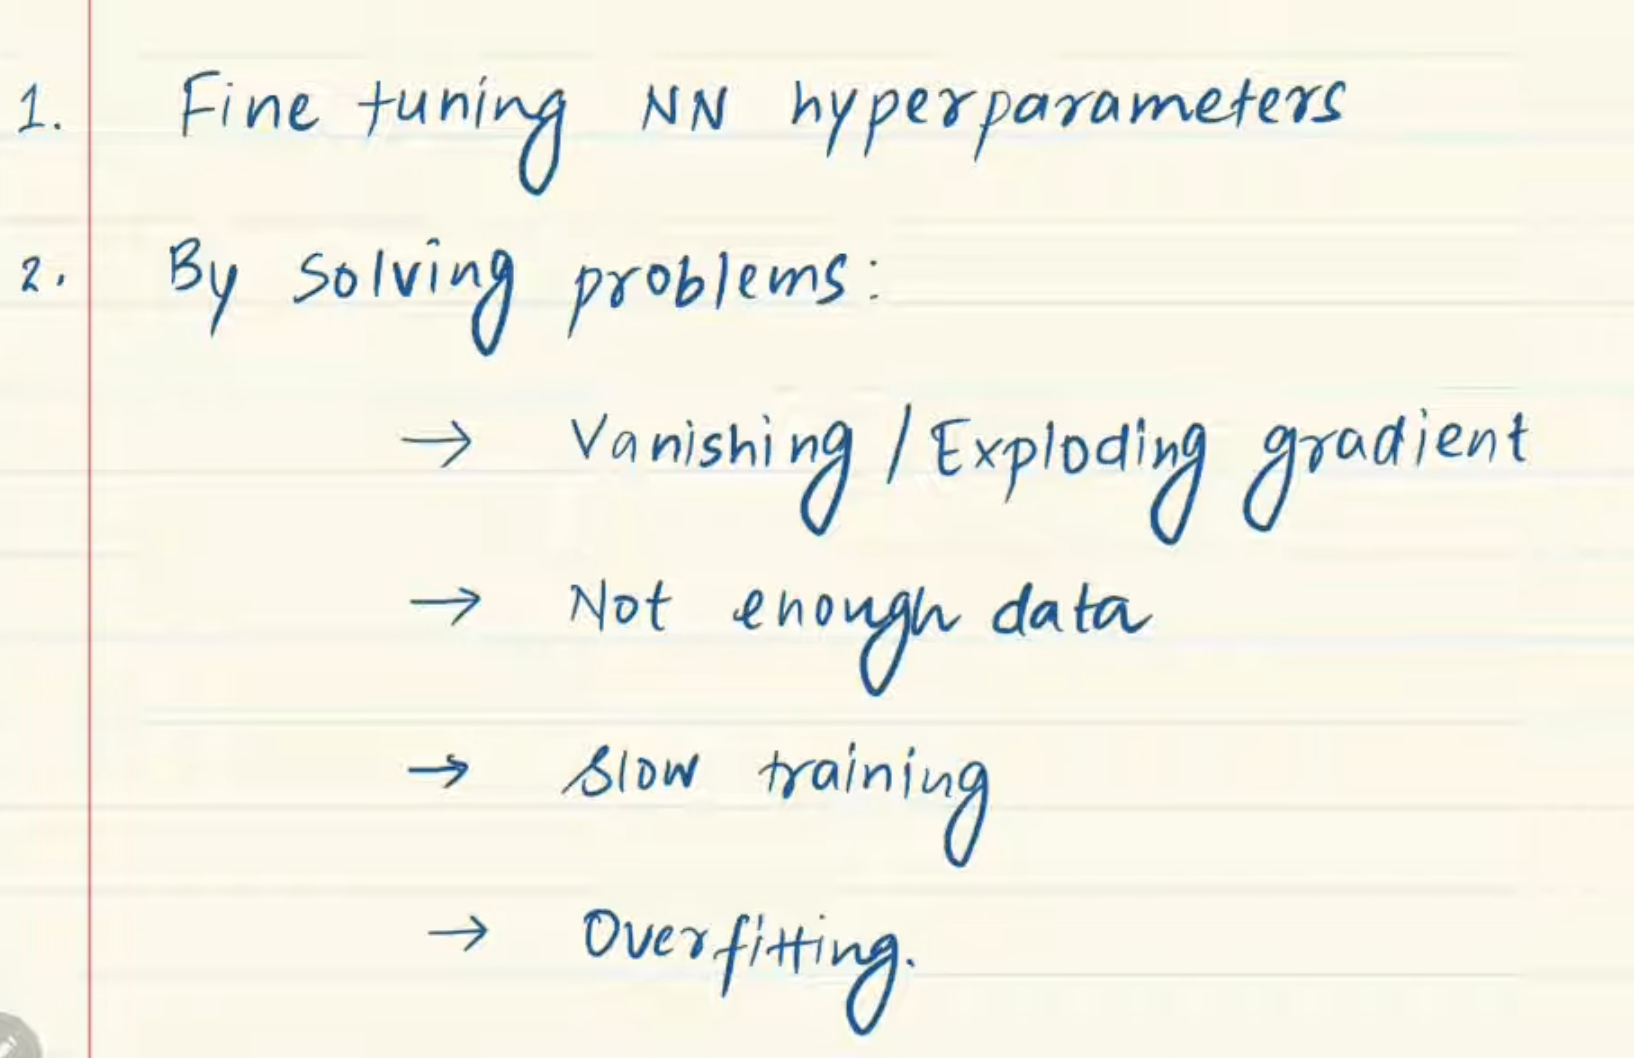

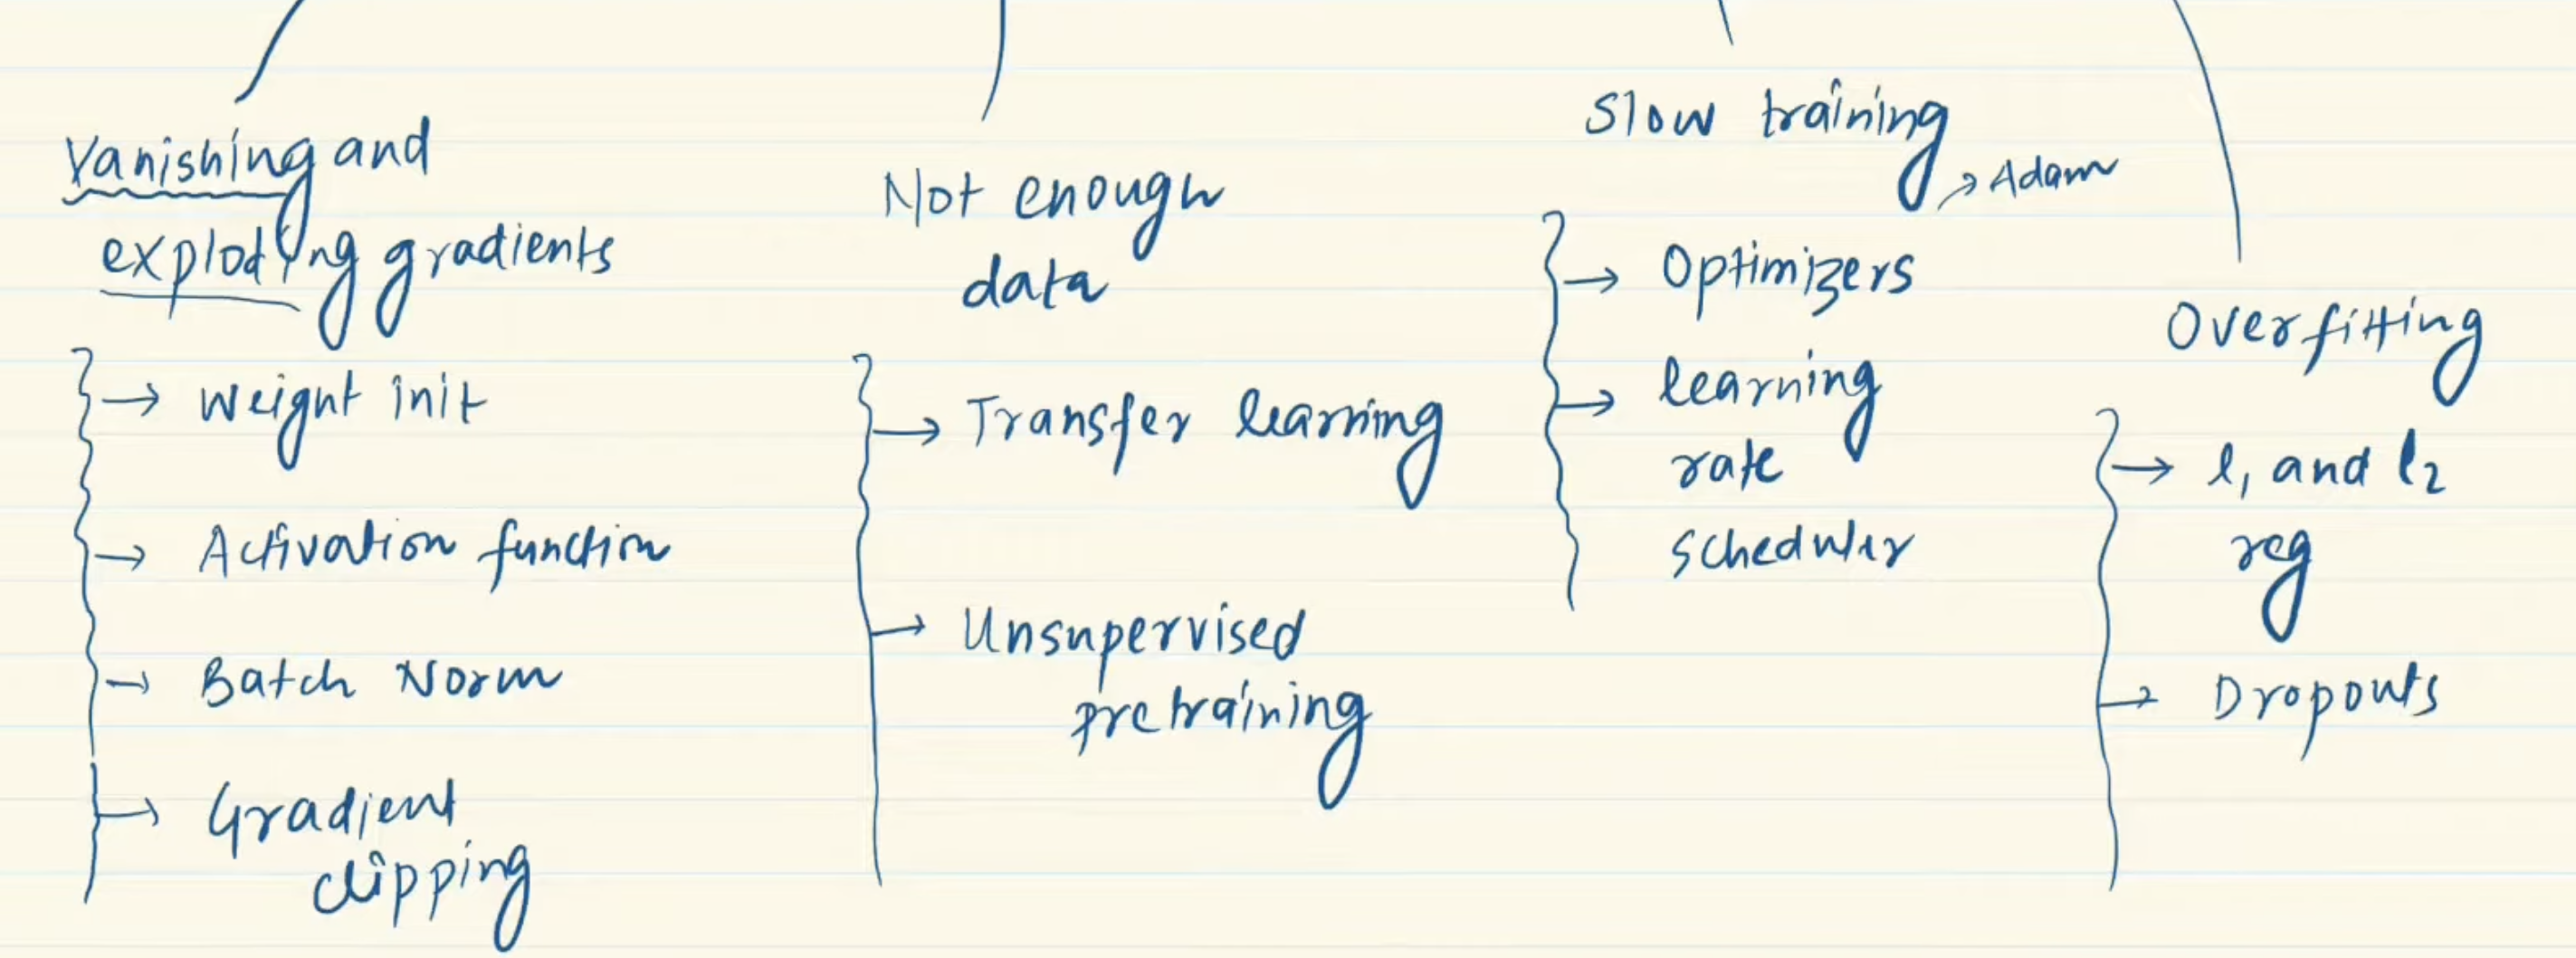

## Topic 1: Introduction to Hyperparameter Tuning (Part 1 – Network Architecture)

### 1. Introduction

**What it is:**  
Hyperparameters are the settings you choose *before* training a neural network — unlike model parameters (weights) that the model learns during training.

**Why important:**  
Even if you have a correctly working neural network, tuning hyperparameters can significantly improve its performance (e.g., pushing accuracy from 90% to 95%+).

**Real‑life use:**  
When building a face recognition system, a deep learning engineer experiments with different numbers of layers and neurons to achieve the best accuracy.

---

### 2. Detailed Explanation

#### What Are Hyperparameters?
Think of a neural network like a recipe. The *ingredients* (data, weights) are adjusted during cooking, but the *kitchen tools and settings* — like oven temperature, baking time, pan size — are **hyperparameters**. You set them before you start.

**Key hyperparameters discussed in this video:**
- Number of hidden layers
- Number of neurons per hidden layer
- Learning rate
- Optimizer choice
- Batch size
- Activation function
- Number of epochs (iterations over data)

#### Number of Hidden Layers – How Many Do You Need?

- **Shallow network (1 hidden layer):** Can work for simple problems, especially if you add many neurons.
- **Deep network (multiple hidden layers):** Often gives better results because deep learning uses **hierarchical representation learning**.

**Analogy – Hierarchical Representation:**  
Imagine recognising a face:
- **Early (shallow) layers** detect primitive features: lines, edges, corners.
- **Later (deep) layers** combine those into shapes (eyes, nose).
- **Final layers** combine shapes into a full face.

A deep network (multiple hidden layers) captures this progression naturally. One very wide layer tries to do all steps at once — less effective.

> **General rule:** More hidden layers are usually better than fewer layers with more neurons. Start with a deeper architecture (e.g., 10 layers of 512 neurons) rather than 1 layer of 5000 neurons.

#### Number of Neurons per Hidden Layer

- **Input layer:** Number of neurons = number of input features (e.g., if predicting placement based on CGPA and attendance, input has 2 neurons).
- **Output layer:**  
  - Regression problem → 1 neuron  
  - Binary classification → 1 neuron  
  - Multi‑class classification → number of neurons = number of classes
- **Hidden layers:** No fixed rule. However:

| Old approach (pyramid structure) | Modern observation |
|----------------------------------|--------------------|
| Decrease neurons layer by layer (e.g., 128 → 64 → 32) | Many experiments show no performance difference; pyramid is not mandatory. |
| Logic: Capture many primitive features early, then combine into fewer complex features | Both pyramid and equal sizes often work similarly. |

**Most important practical rule:**
> **Always put sufficient (or even more) neurons in the earlier layers.**  
> If you ignore some primitive features at the first layer, you cannot recover them later.

**Start big, then reduce if needed:**
- Start with more neurons/layers.
- If you see **overfitting** (training accuracy high, validation accuracy low), reduce gradually.
- If no overfitting, you can increase further.

**Transfer learning advantage:**  
With many early‑layer neurons, you can reuse a model trained on one problem (e.g., face detection) for another problem (e.g., monkey face detection) — the primitive feature detection is already learned.

---

### 3. Key Points

- Hyperparameters are **set before training**; they control the learning process.
- **Deeper networks** (more hidden layers) generally outperform shallow wide networks due to hierarchical feature learning.
- **Input & output neuron counts** are fixed by your data and problem type.
- **Hidden layer neuron count** – start with “sufficient” (on the larger side), then reduce if overfitting appears.
- The **pyramid structure** (decreasing neurons) is optional; equal sizes work too.
- More early‑layer neurons help capture **primitive features** – you cannot recover missed features later.
- **Transfer learning** becomes possible when early layers are rich and reusable.

---

### 4. Common Mistakes

| Mistake | Why it’s wrong | How to avoid |
|---------|----------------|---------------|
| Starting with too few neurons/layers | May miss key patterns; model underperforms | Begin with a larger architecture, then simplify if needed |
| Automatically using pyramid structure | Unnecessary; no proven benefit | Try equal sizes first; only reduce if overfitting |
| Ignoring early layer size | Lost primitive features cannot be regained | Always keep enough neurons in first hidden layer |
| Forgetting output layer rules | Wrong output shape for your problem | Map problem type → regression/classification → neuron count |

---

### 5. Interview / Exam Questions

**Q1:** You are building a neural network for a 10‑class image classification task with 784 input pixels. How many neurons in the input and output layers?  
**A:** Input = 784 (pixel features). Output = 10 (one per class).

**Q2:** Why is a deep network (many hidden layers) often better than a single wide hidden layer?  
**A:** Deep networks learn hierarchical representations — primitive features in early layers, complex features in deeper layers. A single layer cannot replicate this step‑wise abstraction effectively.

**Q3:** You trained a model and see high training accuracy but low validation accuracy. What hyperparameter change might help?  
**A:** Reduce the number of neurons or layers (overfitting). Also consider adding dropout or regularisation (covered in later topics).

**Q4:** What is the “sufficient neurons” rule for hidden layers?  
**A:** Start with enough neurons to capture all primitive features at the first layer; if overfitting occurs, reduce gradually. Do not start too small.

---

### 6. Revision Notes

- **Hyperparameters** = settings you choose (layers, neurons, learning rate, batch size, etc.)
- **Hidden layers** → more is better (deep > wide)
- **Neurons per layer:**
  - Input = features
  - Output = 1 (regression/binary) or = classes (multi‑class)
  - Hidden = start large → reduce only if overfitting
- **Pyramid structure** optional (no clear benefit)
- **Early layers must be large enough** to capture primitive patterns
- **Transfer learning** = reuse early layers of a trained model

---


## Topic 2: Learning Rate, Optimizers, and Batch Size

### 1. Introduction

**What it is:**  
Learning rate controls how big a step the model takes when adjusting weights during training. Optimizers are algorithms that use the learning rate to update weights efficiently. Batch size determines how many training examples are processed before each update.

**Why important:**  
Even with a perfect network architecture, wrong learning rate or batch size can make training too slow, unstable, or fail completely.

**Real‑life use:**  
Training a self‑driving car model – if learning rate is too high, the model jumps randomly and never learns roads; too low, it takes weeks to train.

---

### 2. Detailed Explanation

#### Learning Rate

**Definition:**  
A small number (e.g., 0.01, 0.001) that multiplies the gradient to determine weight updates.

**Analogy – Walking down a hill:**
- **High learning rate (big steps):** You might jump over the valley and miss the bottom. The model "bounces" and never settles.
- **Low learning rate (tiny steps):** You walk extremely slowly – safe but takes forever.
- **Right learning rate:** Steady, efficient descent to the minimum.

**What happens if it's wrong:**
| Problem | Effect |
|---------|--------|
| Too high | Model overshoots, doesn't converge, loss fluctuates wildly |
| Too low | Training is extremely slow, may get stuck in poor solutions |

#### Optimizers

**What they are:**  
Optimizers are algorithms that use the learning rate to update weights. Basic gradient descent is simple, but modern optimizers speed up convergence.

**Note from transcript:**  
Vanilla (basic) gradient descent is rarely used alone. Better optimizers (like Adam, RMSprop) will be covered in future videos. Optimizers help gradient descent:
- Converge faster
- Reach better (more stable) solutions

#### Batch Size – Three Types of Gradient Descent

| Type | Batch Size | Update frequency | Speed | Result quality |
|------|-----------|------------------|-------|----------------|
| **Batch GD** | All data | Once per full pass of all data | Slow per update | Stable but slow |
| **Stochastic GD (SGD)** | 1 sample | After every single example | Very fast updates | Noisy, less stable |
| **Mini‑batch GD** | 32, 64, 128, etc. | After each batch (e.g., every 32 examples) | Balanced | Good generalisation |

**Mini‑batch example:**  
If you have 1000 training samples and batch size = 32:
- Round 1: Update weights after samples 1–32
- Round 2: Update after samples 33–64
- … and so on. Each full pass through all data = 1 epoch.

#### How Batch Size Affects Training – Two Competing Views

**View 1 – Small batch size (e.g., 32):**
- ✅ Training is slower (more updates needed)
- ✅ Often gives **better generalisation** (performs well on new, unseen data)
- ✅ Preferred by many practitioners for accuracy

**View 2 – Large batch size (e.g., 192, 512, or maximum your GPU RAM allows):**
- ✅ Training is faster (fewer updates per epoch)
- ❌ May give poorer generalisation
- ✅ Can work well if combined with **learning rate warmup**

**Learning Rate Warmup (a solution for large batches):**
- Start training with a **small** learning rate
- Gradually **increase** the learning rate as training progresses
- Combines speed of large batches with good results

> **Practical advice from the transcript:**  
> Try the small batch approach first (good results). If that doesn't work well or is too slow, try large batch + learning rate warmup. Choose based on your results and computational resources.

#### Number of Epochs

**Definition:**  
One epoch = one complete pass of all training data through the model.

**How many epochs?**  
- No fixed number – depends on your data and model
- Don't just run 1000 epochs blindly
- Use **early stopping** (next topic) – stop automatically when performance stops improving

**What happens if you train too long?**  
- Model starts overfitting (memorising training data, failing on new data)
- No further improvement in validation performance

---

### 3. Key Points

- **Learning rate** – balance between speed and stability. Too high = diverges, too low = slow.
- **Optimizers** – advanced update rules (Adam, RMSprop) outperform vanilla gradient descent.
- **Batch size options:**
  - Batch GD (all data) – stable but slow
  - SGD (1 sample) – noisy
  - Mini‑batch (32, 64, 128) – best balance
- **Small batch size** → slower training, often better results
- **Large batch size** → faster training, can work well with **learning rate warmup**
- **Epochs** – not a hyperparameter to guess; use early stopping instead

---

### 4. Syntax / Structure (How These Concepts Appear in Code)

*Note: Actual code examples will appear in later videos, but here is the conceptual structure:*

```
model.compile(
    optimizer='adam',          # Optimizer choice
    learning_rate=0.001       # Learning rate
)

model.fit(
    X_train, y_train,
    batch_size=32,            # Mini-batch size
    epochs=100                # Max epochs (early stopping will override)
)
```

---

### 5. Common Mistakes

| Mistake | Why it fails | Fix |
|---------|--------------|-----|
| Learning rate too high | Loss goes to infinity or NaN | Reduce by 10× or 100× |
| Learning rate too low | No progress after hours | Increase gradually |
| Always using batch size = 32 | Might be suboptimal for your GPU/data | Experiment with 64, 128 |
| Running fixed epochs (e.g., always 1000) | Wastes time or overfits | Use early stopping |
| Using vanilla gradient descent only | Slower convergence | Switch to Adam or RMSprop |

---

### 6. Interview / Exam Questions

**Q1:** You increase batch size from 32 to 256. What happens to training speed and generalisation?  
**A:** Speed increases (fewer updates). Generalisation may decrease unless you use learning rate warmup.

**Q2:** Your loss is oscillating wildly and not decreasing. What hyperparameter is most likely wrong?  
**A:** Learning rate is too high.

**Q3:** What is learning rate warmup and why use it?  
**A:** Start with small learning rate and gradually increase. It allows large batch training to achieve good generalisation while remaining fast.

**Q4:** Compare batch GD, SGD, and mini‑batch GD.  
**A:**  
- Batch GD: update after all data – stable, slow  
- SGD: update after each sample – noisy, fast updates  
- Mini‑batch: update after fixed small set – balanced approach

---

### 7. Revision Notes

- **Learning rate (LR)** – step size for weight updates
  - Too high = unstable / no convergence
  - Too low = very slow
- **Optimizer** – algorithm using LR (Adam is common; more details later)
- **Batch size:**
  - Small (32) → slower, better results
  - Large (192+) → faster, may need **warmup**
- **Warmup** = start LR small → increase LR during training
- **Epoch** = one full pass through all training data
- **Don't guess epochs** → use early stopping

---



## Topic 3: Vanishing and Exploding Gradients – Problems & Solutions

### 1. Introduction

**What it is:**  
During backpropagation, gradients (the signals used to update weights) can become extremely small (vanish) or extremely large (explode) as they travel backwards through deep networks.

**Why important:**  
- **Vanishing gradients** → early layers learn nothing or stop learning entirely → model underperforms.
- **Exploding gradients** → weights become huge → training becomes unstable or fails completely.

**Real‑life use:**  
Training a 50‑layer deep neural network for language translation. Without proper techniques, the first 40 layers never learn anything useful because gradients vanish before reaching them.

---

### 2. Detailed Explanation

#### The Problem – What Happens During Backpropagation?

**Analogy – Whisper Game (Chinese Whispers):**
- You whisper a message to Person 1.
- Person 1 whispers to Person 2.
- This continues through 50 people.
- By the end, the message is either:
  - **Vanished** – becomes silence (nothing left) → *vanishing gradient*
  - **Exploded** – becomes gibberish screaming (distorted, huge) → *exploding gradient*

**In neural networks:**
- Gradients start at the output layer and multiply as they move backward.
- Each layer multiplies the gradient by small numbers (<1) → gets smaller and smaller (vanishing)
- Or by large numbers (>1) → gets bigger and bigger (exploding)

#### Common Causes

| Cause | Leads to |
|-------|----------|
| Using **sigmoid** or **tanh** activation functions | Vanishing gradients (their derivatives are ≤ 0.25) |
| Very **deep networks** (many layers) | Both vanishing or exploding |
| Poor **weight initialization** | Either problem |
| Large **learning rate** | Exploding gradients |

#### Vanishing Gradients – Detailed

**What happens:**
- Gradients become extremely tiny (e.g., 0.0000001)
- Weight updates become negligible
- Early layers practically stop learning
- Training seems "stuck" – loss doesn't decrease

**Example with sigmoid:**  
Derivative of sigmoid is at most 0.25. Multiply by 0.25 across 10 layers:  
0.25¹⁰ ≈ 0.00000095 – almost zero!

**Symptoms:**
- Loss decreases very slowly or not at all
- Early layer weights barely change
- Model performs poorly even after many epochs

#### Exploding Gradients – Detailed

**What happens:**
- Gradients become extremely large (e.g., > 1e8)
- Weight updates become huge jumps
- Model parameters become NaN (not a number) or infinity
- Training crashes

**Symptoms:**
- Loss suddenly becomes NaN or infinity
- Model weights show extremely large values
- Training halts with errors

---

### 3. Solutions – How to Fix Both Problems

| Problem | Solutions (from transcript) |
|---------|----------------------------|
| **Vanishing gradients** | 1. Better weight initialization<br>2. Change activation function (e.g., ReLU)<br>3. Batch normalization<br>4. Residual networks / skip connections (future topic) |
| **Exploding gradients** | 1. Gradient clipping<br>2. Proper initialization<br>3. Smaller learning rate |

#### Solution 1: Proper Weight Initialization

**What it is:**  
How you set initial weights before training starts.

**Common mistake (bad approach):**  
Random very small weights (e.g., all near 0.01) or random large weights.

**Better approach (to be covered in future videos):**  
Techniques like Xavier/Glorot initialization or He initialization – designed to keep gradients in a healthy range.

#### Solution 2: Change Activation Function

| Activation | Gradient behavior | Use for vanishing problem? |
|------------|------------------|---------------------------|
| Sigmoid | Small derivatives (max 0.25) | ❌ Avoid |
| Tanh | Derivatives up to 1.0 | Better but still can vanish |
| **ReLU** | Derivative = 1 for positive inputs | ✅ **Recommended** – avoids vanishing |

> **Key insight from transcript:** If you have vanishing gradient problems, switch your activation function to ReLU (or variants like Leaky ReLU).

#### Solution 3: Batch Normalization

**What it is:**  
A technique that normalizes layer outputs during training. (Will be covered in detail in future videos.)

**How it helps:**  
- Keeps activations in a stable range
- Reduces vanishing/exploding problems
- Modern standard for deep networks

#### Solution 4: Gradient Clipping (for Exploding Gradients)

**What it is:**  
If a gradient exceeds a threshold, you "clip" it down to that threshold.

**Simple concept:**
```
If gradient > threshold:
    gradient = threshold
If gradient < -threshold:
    gradient = -threshold
```

**When to use:**  
Specifically for **exploding gradients** – clip large gradients before they destabilize training.

---

### 4. Key Points

- **Vanishing gradients** – gradients become too small → early layers stop learning
- **Exploding gradients** – gradients become too large → training crashes
- **Sigmoid/tanh** activation functions commonly cause vanishing problems
- **ReLU** activation largely solves vanishing gradients
- **Proper weight initialization** prevents both problems from the start
- **Batch normalization** is a modern solution (details in future videos)
- **Gradient clipping** specifically fixes exploding gradients

---

### 5. Common Mistakes

| Mistake | Why it's wrong | Fix |
|---------|----------------|-----|
| Using sigmoid in deep networks | Guarantees vanishing gradients | Switch to ReLU |
| Random tiny weights everywhere | May still cause vanishing | Use proper initialization (Xavier/He) |
| Ignoring gradient values | Don't know if problem exists | Monitor gradients during training |
| No gradient clipping for RNNs | Exploding gradients common | Apply gradient clipping |
| Blaming learning rate only | Might be activation/initialization | Check all causes |

---

### 6. Interview / Exam Questions

**Q1:** You are training a 20‑layer network with sigmoid activations. Loss hasn't decreased in 10 epochs. What is the most likely problem?  
**A:** Vanishing gradients. Sigmoid's small derivatives multiply across layers, making gradients near zero. Early layers cannot learn.

**Q2:** How does switching to ReLU help vanishing gradients?  
**A:** ReLU's derivative is 1 for positive inputs (and 0 for negative). Gradients don't shrink when passing through active neurons, so they survive through many layers.

**Q3:** Your training loss suddenly becomes NaN after a few batches. What happened?  
**A:** Likely exploding gradients – weight updates became huge, causing overflow to NaN. Solution: gradient clipping and/or smaller learning rate.

**Q4:** Name four ways to prevent vanishing gradients.  
**A:** (1) Use ReLU activation, (2) Proper weight initialization, (3) Batch normalization, (4) Shallower architecture or residual connections.

**Q5:** What is gradient clipping?  
**A:** Capping gradients at a maximum value before updating weights. Prevents exploding gradients.

---

### 7. Revision Notes

| Problem | What happens | Solutions |
|---------|--------------|-----------|
| **Vanishing** | Gradients → 0; early layers stop learning | ReLU, better initialization, batch norm |
| **Exploding** | Gradients → huge; training crashes | Gradient clipping, lower LR, proper init |

**Quick fixes:**
- ✅ Use **ReLU** (not sigmoid/tanh)
- ✅ Use **proper weight initialization** (not random tiny)
- ✅ Consider **batch normalization** (modern standard)
- ✅ For RNNs/deep nets: **gradient clipping**

**Remember the whisper game analogy:**
- Vanishing = message becomes silence
- Exploding = message becomes screaming gibberish

---


## Topic 4: Data Problems, Slow Training, and Overfitting

### 1. Introduction

**What it is:**  
Four major practical problems that hurt neural network performance:
1. **Data problems** – not enough data or poor quality data
2. **Slow training** – model takes too long to learn
3. **Overfitting** – model memorizes training data but fails on new data
4. **Vanishing/exploding gradients** (already covered in Topic 3)

**Why important:**  
Even with perfect hyperparameters, these problems can make your model useless. Knowing how to identify and fix each one is essential for real‑world deep learning.

**Real‑life use:**  
A medical image diagnosis model with only 100 X‑ray images will overfit badly. A self‑driving car model that trains for 3 months is impractical. You need solutions for both.

---

### 2. Detailed Explanation

#### Problem 1: Not Enough Data

**The reality:**  
Deep learning is **data‑hungry**. It needs large amounts of data to perform well.

**Analogy:**  
Learning to recognize cats from just 3 photos → you'll memorize those specific cats, not learn general "cat-ness". With 10,000 photos, you learn real patterns.

**Symptoms:**
- Model performs well on training data but poorly on test data (overfitting)
- Small changes in training data cause very different results

**Solutions from transcript:**

| Solution | What it does |
|----------|--------------|
| **Transfer learning** | Use a model pre‑trained on a large dataset (e.g., ImageNet). Reuse its early layers (primitive feature detectors). Train only the last few layers on your small dataset. |
| **Data augmentation** | Create more data from existing data – rotate, flip, zoom, shift images (future topic) |
| **Unsupervised/semi‑supervised pre‑training** | Pre‑train on unlabeled data, then fine‑tune on labeled data |

**Transfer learning explained:**
1. Someone else trains a model on a huge dataset (e.g., 1 million images of general objects)
2. Early layers learn primitive features (edges, shapes, textures)
3. You take that model and replace the last few layers
4. Train only the new layers on your small dataset (e.g., 100 monkey face images)
5. Result: Good performance with little data

---

#### Problem 2: Slow Training

**What it means:**  
The model takes too many hours or days to train, making experimentation impractical.

**Solutions from transcript:**

| Solution | How it helps |
|----------|--------------|
| **Better optimizers** | Adam, RMSprop converge faster than vanilla gradient descent |
| **Learning rate schedulers** | Adjust learning rate during training for faster convergence |
| **Batch size tuning** | Larger batches can speed up training (with warmup) |
| **Faster hardware** | GPUs, TPUs (practical but expensive) |

**Learning rate scheduler:**
- Changes learning rate dynamically during training
- Example: Start with LR = 0.01, reduce by half every 10 epochs
- Helps training proceed faster early and fine‑tune later

**Note from transcript:**  
Many advanced optimizers and schedulers will be covered in detail in future videos.

---

#### Problem 3: Overfitting (and Underfitting)

**Definitions:**

| Term | What it means | Signs |
|------|---------------|-------|
| **Underfitting** | Model is too simple – cannot learn patterns | Poor performance on BOTH training and test data |
| **Overfitting** | Model memorizes training data – fails to generalise | High training accuracy, low test/validation accuracy |

**Analogy – Exam studying:**
- **Underfitting** = Studied only 2 pages for a 100‑page exam → fails everything
- **Overfitting** = Memorized the answer key of 1 practice test → fails when questions are rephrased
- **Good fit** = Understood concepts → answers any variation

**Why neural networks overfit easily:**
- Neural networks have many parameters (millions in deep networks)
- Enough parameters to memorize the entire training set
- Model learns noise and exceptions instead of real patterns

**Solution from transcript: Regularization**

**Dropout** (mentioned specifically):
- During training, randomly "drop" (ignore) a percentage of neurons
- Forces the network to learn redundant representations
- Prevents reliance on any single neuron
- Common values: dropout = 0.2 to 0.5 (20-50% of neurons dropped)

**Other regularization methods (future topics):**
- L1/L2 regularization
- Early stopping
- Data augmentation

**General approach to overfitting:**
```
If overfitting detected:
    - Add dropout
    - Reduce number of layers/neurons
    - Add L1/L2 regularization
    - Get more data
    - Use data augmentation
```

---

### 4. Complete Problem‑Solution Summary Table

| Problem | Symptoms | Solutions |
|---------|----------|-----------|
| **Not enough data** | Overfitting with small dataset | Transfer learning, data augmentation, pre‑training |
| **Slow training** | Takes days/weeks to converge | Better optimizers, LR schedulers, batch tuning |
| **Overfitting** | High train accuracy, low test accuracy | Dropout, reduce model size, regularization |
| **Underfitting** | Low accuracy on both train and test | Increase model size (layers/neurons), train longer |
| **Vanishing gradients** | Early layers don't learn | ReLU, batch norm, proper init (Topic 3) |
| **Exploding gradients** | Loss becomes NaN | Gradient clipping (Topic 3) |

---

### 5. Key Points

- **Deep learning needs lots of data** – without it, use transfer learning
- **Transfer learning** = reuse someone else's pre‑trained model (especially early layers)
- **Slow training** can be fixed with better optimizers (Adam) and learning rate schedules
- **Overfitting** = memorization, not learning – very common in deep networks
- **Dropout** is a primary weapon against overfitting (randomly turn off neurons during training)
- **Regularization** (dropout, L1/L2) reduces overfitting
- If overfitting occurs, **reduce model complexity**; if underfitting, **increase model complexity**

---

### 6. Common Mistakes

| Mistake | Why it's wrong | Fix |
|---------|----------------|-----|
| Training a deep network on 100 images from scratch | Will severely overfit | Use transfer learning instead |
| No dropout in a large network | Almost guaranteed overfitting | Add dropout layers (0.2–0.5) |
| Adding dropout when underfitting | Makes underfitting worse | Remove dropout, increase model size |
| Ignoring slow training, just waiting longer | Wastes time | Switch to Adam optimizer, tune batch size |
| Using more data before trying transfer learning | Data collection is expensive | Try transfer learning first |

---

### 7. Interview / Exam Questions

**Q1:** You have only 500 labeled images for a classification task. Your model overfits badly. What two solutions would you try first?  
**A:** (1) Transfer learning – use a pre‑trained model (e.g., VGG16 on ImageNet), (2) Data augmentation – create more images by rotating/flipping.

**Q2:** What is dropout and why does it prevent overfitting?  
**A:** Dropout randomly ignores a fraction of neurons during each training batch. This prevents neurons from co‑adapting too specifically to the training data and forces the network to learn robust, redundant representations.

**Q3:** Your training accuracy is 99% but validation accuracy is only 65%. What is happening?  
**A:** Overfitting. The model has memorized the training data but cannot generalize to new data.

**Q4:** How is transfer learning different from training from scratch?  
**A:** Training from scratch initializes weights randomly and learns everything from your data. Transfer learning starts with weights from a model pre‑trained on a large dataset, reuses early layers (primitive feature detectors), and only retrains later layers on your specific task.

**Q5:** You increase model size (more layers/neurons) and validation accuracy drops while training accuracy rises. What should you do?  
**A:** Add dropout or other regularization. If overfitting persists, reduce model size back down.

---

### 8. Revision Notes

| Problem | Quick Fix |
|---------|-----------|
| **Small dataset** | 👉 Transfer learning |
| **Slow training** | 👉 Adam optimizer + LR scheduler |
| **Overfitting** | 👉 Dropout + reduce model size |
| **Underfitting** | 👉 Increase model size (layers/neurons) |

**Dropout in one line:**  
Randomly turn off neurons during training → prevents overfitting

**Transfer learning in one line:**  
Use early layers from a pre‑trained model → works well with small data

**Remember:**  
- Deep networks **need** regularization (dropout is your friend)
- Small data + deep network = overfitting (use transfer learning)
- Monitor both train AND validation accuracy to diagnose problems

---



## Topic 5: Early Stopping and Next Steps Roadmap

### 1. Introduction

**What it is:**  
Early stopping is a technique that monitors your model's performance during training and automatically stops when performance stops improving. The roadmap outlines what topics will be covered in future videos to continue improving neural network performance.

**Why important:**  
Without early stopping, you waste time training beyond the point of improvement, and you risk overfitting. The roadmap helps you understand what remains to learn.

**Real‑life use:**  
Training a model for 1000 epochs when it stops improving at epoch 200 wastes hours or days. Early stopping saves that time automatically.

---

### 2. Detailed Explanation

#### Early Stopping – What and Why

**The problem it solves:**  
As training continues, validation performance eventually plateaus or worsens (overfitting). Training beyond this point is useless.

**How it works:**
1. After each epoch (or every N batches), measure validation performance
2. If validation performance hasn't improved for a certain number of epochs (called **patience**)
3. Stop training automatically
4. Restore the best model weights found during training

**Analogy – Cooking pasta:**
- You taste the pasta every 30 seconds
- When it's perfectly cooked (validation best), note that moment
- Keep cooking a bit more to be sure
- If it starts getting mushy (performance drops), stop and go back to the perfect moment

**The "callback" concept:**
- Early stopping is implemented as a **callback** – a function that runs at specific times during training
- It checks conditions and takes actions (e.g., stop training, save weights)

**Patience parameter:**
- How many epochs to wait after the last improvement before stopping
- Example: patience = 10 → stop if no improvement for 10 consecutive epochs
- Prevents stopping due to random fluctuations

**Why not just set a fixed number of epochs?**
| Fixed epochs | Early stopping |
|--------------|----------------|
| Guess how many epochs you need | Automatically finds the right number |
| May stop too early (underfitting) | Stops only when no more improvement |
| May run too long (waste time, overfit) | Prevents overfitting automatically |
| Requires manual tuning each experiment | Set once, works across experiments |

---

### 3. The Complete Improvement Roadmap

The transcript outlines future videos covering these topics in detail:

#### Category 1: Hyperparameter Tuning (Detailed)

| Hyperparameter | What will be covered |
|----------------|----------------------|
| Number of hidden layers | How to decide for your problem |
| Number of neurons per layer | Practical rules and experiments |
| Learning rate | Setting and scheduling strategies |
| Optimizer | Adam, RMSprop, SGD with momentum |
| Batch size | Tuning for speed vs. accuracy |
| Activation function | When to use ReLU, Leaky ReLU, Swish, etc. |
| Number of epochs | Using early stopping instead of guessing |

#### Category 2: Problem Solving (4 Major Problems)

| Problem | Solution topics to cover |
|---------|-------------------------|
| **Vanishing/exploding gradients** | Weight initialization (Xavier, He), batch normalization, gradient clipping, ReLU variants |
| **Not enough data** | Transfer learning (detailed), data augmentation, semi‑supervised learning |
| **Slow training** | Optimizers deep dive, learning rate schedulers, one‑cycle policy |
| **Overfitting** | Dropout (detailed), L1/L2 regularization, batch normalization (also helps overfitting), cross‑validation |

#### Specific Techniques Mentioned for Future Videos

| Technique | Purpose |
|-----------|---------|
| **Weight initialization (Xavier/Glorot, He)** | Prevent vanishing/exploding gradients |
| **Batch normalization** | Normalize layer outputs – helps both vanishing gradients and overfitting |
| **Gradient clipping** | Fix exploding gradients |
| **ReLU and variants** | Replace sigmoid/tanh to avoid vanishing |
| **Dropout** | Primary regularization against overfitting |
| **Learning rate schedulers** | Dynamic LR for faster/better convergence |
| **Callbacks (including early stopping)** | Automated training control |

---

### 4. Key Points

- **Early stopping** = automatically stop training when validation performance plateaus or worsens
- Uses a **patience** parameter (e.g., stop after 10 epochs of no improvement)
- Restores the **best model** (not the final one)
- Implemented as a **callback** (function that runs during training)
- **Don't guess epochs** – use early stopping

**Roadmap summary:**
1. Already covered: Hyperparameter introduction (layers, neurons, learning rate, batch size)
2. Already covered: Four major problems and their solutions
3. Future videos: Deep dives into each solution – initialization, batch norm, dropout, optimizers, schedulers, callbacks

---

### 5. Common Mistakes

| Mistake | Why it's wrong | Fix |
|---------|----------------|-----|
| Training for fixed 1000 epochs every time | Wastes time or overfits | Use early stopping |
| Setting patience = 0 | Stops at first fluctuation | Use patience = 5–20 |
| Not saving the best model | Final model may be worse than earlier best | Save checkpoint of best validation performance |
| Ignoring validation metrics during training | Don't know when to stop | Monitor validation loss/accuracy |
| Trying to tune everything at once | Confusing, time‑consuming | Follow roadmap: one technique at a time |

---

### 6. Interview / Exam Questions

**Q1:** What is early stopping and what problem does it solve?  
**A:** Early stopping monitors validation performance during training and stops automatically when improvement stops. It prevents wasting time and reduces overfitting.

**Q2:** What does the "patience" parameter mean in early stopping?  
**A:** Patience is the number of epochs to wait after the last improvement before stopping. It prevents stopping due to random fluctuations.

**Q3:** After early stopping stops training, which model weights are used?  
**A:** The weights from the epoch with the best validation performance (not the final epoch's weights).

**Q4:** Name three techniques mentioned for fixing vanishing gradients in future videos.  
**A:** (1) Xavier/He weight initialization, (2) Batch normalization, (3) Switching to ReLU activation.

**Q5:** What is the main technique mentioned for fixing overfitting?  
**A:** Dropout (randomly dropping neurons during training).

---

### 7. Revision Notes

**Early stopping at a glance:**
```
Monitor validation performance
If no improvement for patience epochs:
    Stop training
    Restore best model
```

**Patience rule of thumb:** Start with 5–10 epochs

**Roadmap – what's next (future videos):**
- Hyperparameter deep dives (each one in detail)
- Weight initialization (Xavier, He)
- Batch normalization
- Dropout
- Optimizers (Adam, RMSprop, etc.)
- Learning rate schedulers
- Callbacks (early stopping, model checkpointing)

**Overall improvement framework:**
1. Start with a reasonable architecture
2. Tune hyperparameters systematically
3. If problems arise, apply specific solutions:
   - Vanishing gradients → ReLU + batch norm
   - Overfitting → dropout + reduce model
   - Slow training → Adam + LR scheduler
   - Small data → transfer learning

---

👉 **This completes all topics from the transcript.** You have covered:
1. Hyperparameter tuning – network architecture
2. Learning rate, optimizers, batch size
3. Vanishing & exploding gradients (problems + solutions)
4. Data problems, slow training, overfitting
5. Early stopping and roadmap

